In [ ]:
import pandas as pd
import numpy as np

from math import erf, exp, log, sqrt
from scipy.stats import norm

import matplotlib.pyplot as plt
import seaborn as sns



In [33]:
sns.set_style("darkgrid")

In [12]:
def _validate_option_inputs(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    volatility: float,
    require_positive_time_and_volatility: bool = False,
) -> None:
    if spot_price <= 0:
        raise ValueError("spot_price debe ser mayor que 0.")
    if strike_price <= 0:
        raise ValueError("strike_price debe ser mayor que 0.")
    if time_to_maturity < 0:
        raise ValueError("time_to_maturity no puede ser negativo.")
    if volatility < 0:
        raise ValueError("volatility no puede ser negativa.")

    if require_positive_time_and_volatility:
        if time_to_maturity <= 0:
            raise ValueError(
                "time_to_maturity debe ser mayor que 0 para calcular griegas."
            )
        if volatility <= 0:
            raise ValueError("volatility debe ser mayor que 0 para calcular griegas.")


def _discount_factor(rate: float, time_to_maturity: float) -> float:
    return np.exp(-rate * time_to_maturity)


def _discounted_spot(
    spot_price: float,
    time_to_maturity: float,
    dividend_yield: float,
) -> float:
    return spot_price * _discount_factor(dividend_yield, time_to_maturity)


def _discounted_strike(
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
) -> float:
    return strike_price * _discount_factor(risk_free_rate, time_to_maturity)


def _forward_price(
    spot_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    dividend_yield: float,
) -> float:
    return spot_price * np.exp((risk_free_rate - dividend_yield) * time_to_maturity)


def d1(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    _validate_option_inputs(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        volatility=volatility,
        require_positive_time_and_volatility=True,
    )

    sqrt_time = np.sqrt(time_to_maturity)
    numerator = np.log(spot_price / strike_price) + (
        risk_free_rate - dividend_yield + 0.5 * volatility**2
    ) * time_to_maturity

    return numerator / (volatility * sqrt_time)


def d2(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    return d1(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    ) - volatility * np.sqrt(time_to_maturity)


def _black_scholes_terms(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float,
) -> tuple[float, float]:
    d1_value = d1(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    d2_value = d1_value - volatility * np.sqrt(time_to_maturity)

    return d1_value, d2_value


def european_call_price(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    """
    Calcula el precio de un call europeo con el modelo de Black-Scholes.
    """
    _validate_option_inputs(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        volatility=volatility,
    )

    if time_to_maturity == 0:
        return float(max(spot_price - strike_price, 0.0))

    if volatility == 0:
        forward_price = _forward_price(
            spot_price=spot_price,
            time_to_maturity=time_to_maturity,
            risk_free_rate=risk_free_rate,
            dividend_yield=dividend_yield,
        )
        discounted_payoff = _discount_factor(risk_free_rate, time_to_maturity) * max(
            forward_price - strike_price,
            0.0,
        )
        return float(discounted_payoff)

    d1_value, d2_value = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )

    call_price = (
        _discounted_spot(spot_price, time_to_maturity, dividend_yield)
        * norm.cdf(d1_value)
        - _discounted_strike(strike_price, time_to_maturity, risk_free_rate)
        * norm.cdf(d2_value)
    )

    return float(call_price)


def call_delta(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    d1_value, _ = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )

    return float(_discount_factor(dividend_yield, time_to_maturity) * norm.cdf(d1_value))


def call_gamma(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    d1_value, _ = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    discounted_density = _discount_factor(dividend_yield, time_to_maturity) * norm.pdf(
        d1_value
    )

    return float(discounted_density / (spot_price * volatility * np.sqrt(time_to_maturity)))


def call_theta(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    d1_value, d2_value = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    discounted_spot = _discounted_spot(spot_price, time_to_maturity, dividend_yield)
    discounted_strike = _discounted_strike(
        strike_price,
        time_to_maturity,
        risk_free_rate,
    )

    theta_value = (
        -discounted_spot * norm.pdf(d1_value) * volatility / (2 * np.sqrt(time_to_maturity))
        - risk_free_rate * discounted_strike * norm.cdf(d2_value)
        + dividend_yield * discounted_spot * norm.cdf(d1_value)
    )

    return float(theta_value)


def call_rho(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    _, d2_value = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    discounted_strike = _discounted_strike(
        strike_price,
        time_to_maturity,
        risk_free_rate,
    )

    return float(time_to_maturity * discounted_strike * norm.cdf(d2_value))


def call_vega(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    d1_value, _ = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    discounted_spot = _discounted_spot(spot_price, time_to_maturity, dividend_yield)

    return float(discounted_spot * norm.pdf(d1_value) * np.sqrt(time_to_maturity))


delta = call_delta
gamma = call_gamma
theta = call_theta
rho = call_rho
vega = call_vega


In [26]:
spots = np.linspace(start=50, stop=120, num=1000)

In [27]:

prices = [european_call_price(
    spot_price=spot,
    strike_price=105,
    time_to_maturity=1.0,
    risk_free_rate=0.05,
    volatility=0.2,
) for spot in spots]


prices[:5]

[0.0009652992340189528,
 0.0009929866120737263,
 0.0010213828157389256,
 0.0010505036263492931,
 0.0010803651176806532]

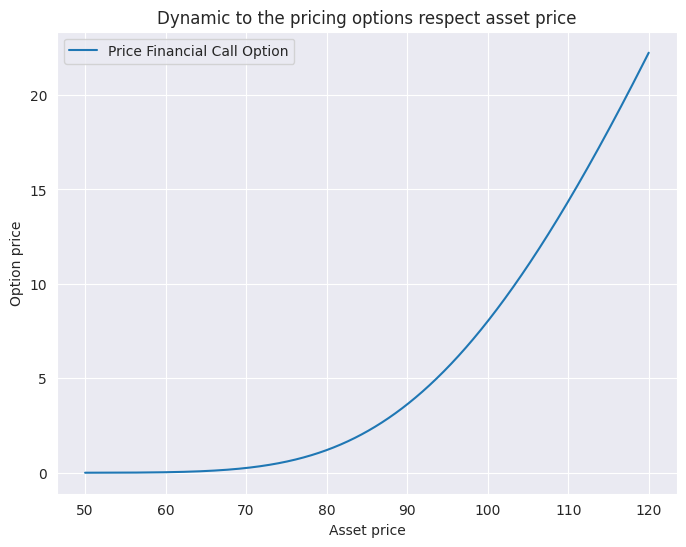

In [40]:
plt.figure(figsize=(8,6))

plt.plot(spots, prices, label = "Price Financial Call Option")

plt.title("Dynamic to the pricing options respect asset price")

plt.xlabel("Asset price")
plt.ylabel("Option price")

plt.legend()
plt.show()